# YZM212 Makine Öğrenmesi
## MLE ile Trafik Modelleme

Ad Soyad:  
Öğrenci No:  
Tarih:

In [3]:
import numpy as np
import scipy.optimize as opt
import matplotlib.pyplot as plt
from scipy.stats import poisson

## Teorik Arka Plan

Poisson dağılımı belirli bir zaman aralığında gerçekleşen olay sayısını modellemek için kullanılır.

Poisson dağılımının olasılık fonksiyonu:

P(k|λ) = (e^-λ * λ^k) / k!

Maximum Likelihood Estimation (MLE) yöntemi ile λ parametresi tahmin edilir.

Poisson dağılımı için MLE sonucu:

λ = veri ortalaması

In [2]:
traffic_data = np.array([12, 15, 10, 8, 14, 11, 13, 16, 9, 12, 11, 14, 10, 15])

traffic_data

array([12, 15, 10,  8, 14, 11, 13, 16,  9, 12, 11, 14, 10, 15])

In [4]:
def negative_log_likelihood(lam, data):

    lam = lam[0]

    if lam <= 0:
        return np.inf

    n = len(data)

    nll = n * lam - np.sum(data) * np.log(lam)

    return nll

In [5]:
initial_guess = [1.0]

result = opt.minimize(
    negative_log_likelihood,
    initial_guess,
    args=(traffic_data,),
    bounds=[(0.001, None)]
)

mle_lambda = result.x[0]
sample_mean = np.mean(traffic_data)

print("MLE lambda:", mle_lambda)
print("Veri ortalaması:", sample_mean)

MLE lambda: 12.14286136240759
Veri ortalaması: 12.142857142857142


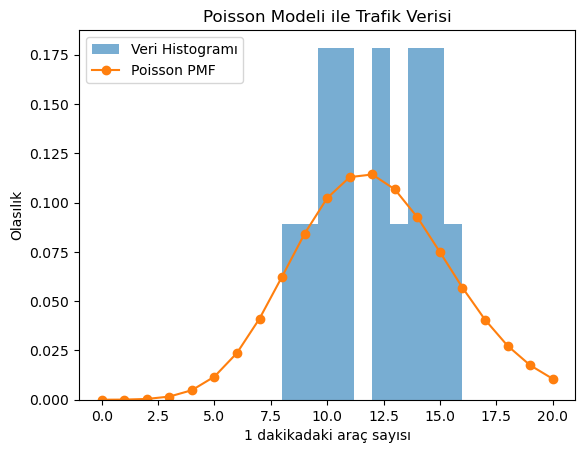

In [6]:
x = np.arange(0, max(traffic_data) + 5)

pmf_values = poisson.pmf(x, mle_lambda)

plt.figure()

plt.hist(traffic_data, bins=10, density=True, alpha=0.6, label="Veri Histogramı")
plt.plot(x, pmf_values, 'o-', label="Poisson PMF")

plt.xlabel("1 dakikadaki araç sayısı")
plt.ylabel("Olasılık")
plt.title("Poisson Modeli ile Trafik Verisi")

plt.legend()

plt.show()

## Outlier Analizi

Veri setine 200 gibi aşırı büyük bir değer eklenirse ortalama ciddi şekilde artar.

Poisson dağılımında MLE tahmini doğrudan ortalamaya eşit olduğu için model bu tür hatalı verilere karşı hassastır.

Bu durum gerçek dünyada yanlış trafik tahminlerine yol açabilir.

In [7]:
traffic_data_outlier = np.append(traffic_data, 200)

result_outlier = opt.minimize(
    negative_log_likelihood,
    [1.0],
    args=(traffic_data_outlier,),
    bounds=[(0.001, None)]
)

mle_lambda_outlier = result_outlier.x[0]
mean_outlier = np.mean(traffic_data_outlier)

print("Outlier sonrası MLE:", mle_lambda_outlier)
print("Outlier sonrası ortalama:", mean_outlier)

Outlier sonrası MLE: 24.666684254362178
Outlier sonrası ortalama: 24.666666666666668
